# Stage 01 v2 — Intraday data preparation (ingestion delgada)

```
S01_intraday_data_preparation_v2.ipynb
```

## Alcance

Esta notebook **no contiene logica de negocio**. Toda la logica vive en
`src/data/s01_intraday_preparation.py`. Esta notebook solo la invoca y
muestra resultados.

- No modifica `notebooks/S01_intraday_data_preparation.ipynb` (v1, evidencia historica intacta).
- No modifica nada de S00 (`config/data_config.yaml`, `src/data/s00_raw_ingestion.py`, artefactos de `data/01_raw/`).
- No construye targets, features, secuencias ni ventanas de modelos -- eso pertenece a etapas posteriores.
- La ventana `04:30-16:00` y los 5 regimenes son decisiones ya aprobadas (ver plan de auditoria S01 v2); esta notebook no los vuelve a comparar.
- La hipotesis de zona horaria de origen **no se asume**: se evalua programaticamente contra 3 candidatos antes de convertir.

## 0. Configuracion del entorno

In [1]:
# Importa Path para trabajar con rutas de archivos y carpetas.
from pathlib import Path

# Importa sys para modificar las rutas donde Python busca módulos.
import sys


def find_project_root(
    start: Path,
    marker: str = "config/intraday_config.yaml",
    max_levels: int = 15
) -> Path:
    """
    Busca hacia arriba la carpeta raíz del proyecto utilizando
    config/intraday_config.yaml como archivo marcador.
    """

    # Convierte la ruta inicial en una ruta absoluta.
    current = start.resolve()

    # Revisa como máximo 15 niveles de carpetas.
    for _ in range(max_levels):

        # Comprueba si el archivo de configuración de S01 existe aquí.
        if (current / marker).exists():

            # Devuelve esta carpeta como raíz del proyecto.
            return current

        # Detiene la búsqueda si ya llegó a la raíz del sistema.
        if current.parent == current:
            break

        # Sube un nivel en la estructura de carpetas.
        current = current.parent

    # Genera un error si no encuentra la raíz del proyecto.
    raise FileNotFoundError(
        f"No se encontro un ancestro de {start} "
        f"que contenga {marker} en {max_levels} niveles"
    )


# Busca la raíz del proyecto desde el directorio de trabajo actual.
PROJECT_ROOT = find_project_root(Path.cwd())

# Muestra la ruta encontrada.
print("Project root:", PROJECT_ROOT)

# Comprueba si la raíz todavía no está en las rutas de importación.
if str(PROJECT_ROOT) not in sys.path:

    # La agrega para poder importar módulos ubicados dentro de src/.
    sys.path.insert(0, str(PROJECT_ROOT))

Project root: C:\Users\heguu\OneDrive\Escritorio\neural_profit


In [2]:
# Importa json para leer o trabajar con archivos en formato JSON.
import json

# Importa matplotlib para crear gráficos.
import matplotlib.pyplot as plt

# Importa pandas para trabajar con DataFrames y archivos tabulares.
import pandas as pd

# Importa el módulo principal de preparación intradía de S01.
# Se utiliza el alias "prep" para llamarlo de forma más corta.
from src.data import s01_intraday_preparation as prep

# Construye la ruta completa al archivo de configuración de S01.
CONFIG_PATH = PROJECT_ROOT / "config" / "intraday_config.yaml"

# Muestra la ruta del archivo de configuración que se utilizará.
print("Config:", CONFIG_PATH)

Config: C:\Users\heguu\OneDrive\Escritorio\neural_profit\config\intraday_config.yaml


## 1. Ejecucion productiva

In [3]:
# Ejecuta todo el proceso de preparación intradía de S01.
# Utiliza la raíz del proyecto y el archivo intraday_config.yaml.
result = prep.run_s01_preparation(
    project_root=PROJECT_ROOT,
    config_path=CONFIG_PATH
)


# Indica si se reutilizó un resultado anterior válido
# o si S01 volvió a procesar los datos.
print("Reutilizo artefacto existente:", result.reused_existing)

# Muestra la ruta del dataset intradía principal en formato Parquet.
print("Parquet:", result.parquet_path)

# Muestra la huella SHA-256 del Parquet para verificar su integridad.
print("SHA-256 Parquet:", result.parquet_sha256)

# Muestra la ruta de la auditoría de jornadas:
# días completos, parciales, ausentes y elegibilidad.
print("Trading day audit:", result.audit_path)

# Muestra la ruta del archivo con la distribución
# de barras por régimen intradía.
print("Regime distribution:", result.regime_dist_path)

# Muestra la ruta del manifiesto con configuración,
# hashes, trazabilidad y características del dataset.
print("Manifest:", result.manifest_path)

# Muestra la ruta del resumen general de S01.
print("Summary:", result.summary_path)

# Muestra la ruta del archivo con los resultados
# de la validación de la zona horaria.
print("TZ validation:", result.tz_validation_path)

Reutilizo artefacto existente: False
Parquet: C:\Users\heguu\OneDrive\Escritorio\neural_profit\data\02_intraday\mnq_intraday_v2.parquet
SHA-256 Parquet: c0b3dae6b64e67a307cf49dec9c3bafa65a23483f6faf6e2d70b1024def4f262
Trading day audit: C:\Users\heguu\OneDrive\Escritorio\neural_profit\data\02_intraday\trading_day_audit_v2.parquet
Regime distribution: C:\Users\heguu\OneDrive\Escritorio\neural_profit\data\02_intraday\regime_distribution_v2.parquet
Manifest: C:\Users\heguu\OneDrive\Escritorio\neural_profit\data\02_intraday\mnq_intraday_v2_manifest.json
Summary: C:\Users\heguu\OneDrive\Escritorio\neural_profit\data\02_intraday\mnq_intraday_v2_summary.json
TZ validation: C:\Users\heguu\OneDrive\Escritorio\neural_profit\data\02_intraday\tz_validation_v2.json


## 2. Validacion programatica de zona horaria (3 hipotesis)

No se asume UTC. Se evaluan `UTC`, `America/New_York` y `America/Chicago`
contra la apertura 09:30 ET, el cierre 16:00 ET y el corte de mantenimiento
~17:00-18:00 ET, separando meses de horario de verano (EDT) y estandar (EST).

In [4]:
# Muestra la tabla comparativa utilizada por S01
# para evaluar las distintas hipótesis de zona horaria.
result.tz_table

,timezone_candidate,opening_alignment,closing_alignment,maintenance_break_alignment,dst_consistency,ambiguous_nonexistent_rows,total_alignment_score,conclusion,confidence_level
0,UTC,1,0,1,0,0,2.0,"opening off by 1min, closing off by 0min, main...",high
1,America/Chicago,29,29,999,30,1,1087.1,"opening off by 29min, closing off by 29min, ma...",low
2,America/New_York,38,59,999,9,1,1105.1,"opening off by 38min, closing off by 59min, ma...",low


In [5]:
# Muestra la zona horaria seleccionada para interpretar los timestamps originales.
print(
    "timezone_selected:",
    result.manifest["timezone"]["timezone_selected"]
)

# Indica el estado de la validación realizada por S01.
print(
    "timezone_validation_status:",
    result.manifest["timezone"]["timezone_validation_status"]
)

# Indica si la zona horaria fue confirmada documentalmente por el proveedor.
print(
    "timezone_provider_confirmation:",
    result.manifest["timezone"]["timezone_provider_confirmation"]
)

# Muestra qué evidencia se utilizó para seleccionar la zona horaria.
print(
    "timezone_evidence:",
    result.manifest["timezone"]["timezone_evidence"]
)

# Muestra el nivel de confianza asignado a la decisión.
print(
    "confidence_level:",
    result.manifest["timezone"]["confidence_level"]
)

timezone_selected: UTC
timezone_validation_status: empirically_supported
timezone_provider_confirmation: False
timezone_evidence: inferred_from_market_structure_and_dst
confidence_level: high


Observaciones:

* **`timezone_selected: UTC`**
  S01 decidió que los horarios originales de los archivos están expresados en **UTC**.

* **`timezone_validation_status: empirically_supported`**
  Esa decisión está respaldada por el comportamiento observado en los datos: los horarios coinciden con apertura, cierre, mantenimiento y cambios estacionales del mercado.

* **`timezone_provider_confirmation: False`**
  El proveedor de los datos no confirmó oficialmente que los timestamps estén en UTC.

* **`timezone_evidence: inferred_from_market_structure_and_dst`**
  La zona horaria se dedujo comparando los datos con la estructura horaria del mercado y con los cambios entre horario de verano e invierno —DST—.

* **`confidence_level: high`**
  La evidencia encontrada es fuerte, por lo que existe alta confianza en que la zona correcta sea UTC.

En términos simples:

> Los archivos no dicen oficialmente “estos horarios son UTC”, pero al comparar sus movimientos y horarios con el mercado, UTC encaja claramente mejor que Chicago o Nueva York.


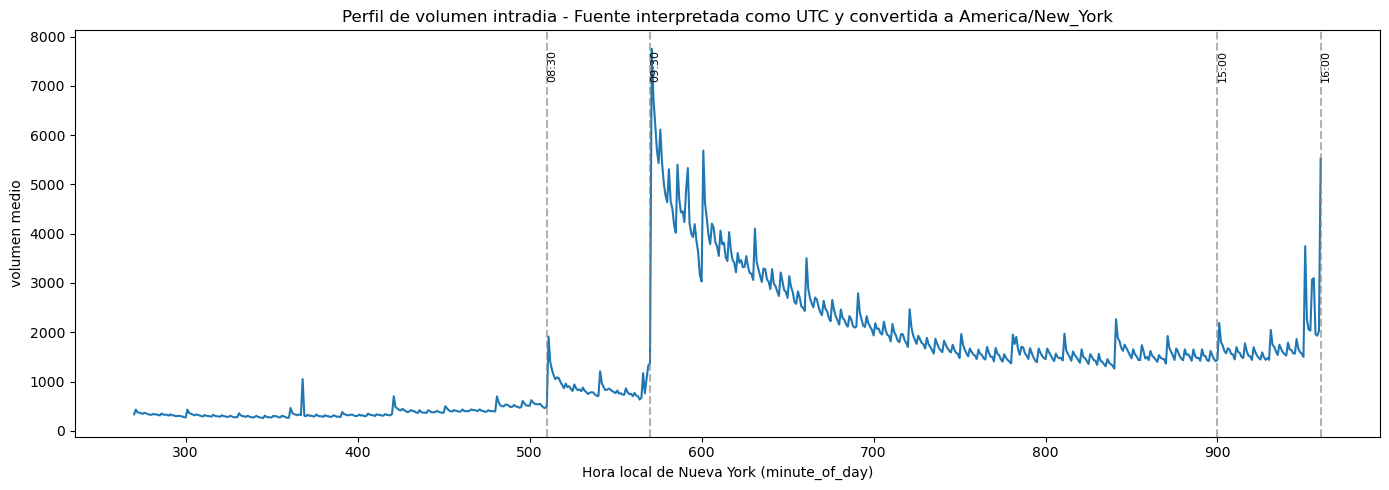

In [6]:
# Obtiene el dataset intradía ya convertido a America/New_York
# y filtrado según la ventana configurada.
df = result.df_window

# Agrupa todas las barras por minuto del día
# y calcula el volumen promedio para cada minuto.
profile = df.groupby("minute_of_day")["volume"].mean()


# Crea una figura de 14 × 5 pulgadas.
fig, ax = plt.subplots(figsize=(14, 5))

# Grafica el volumen promedio según el minuto del día.
ax.plot(profile.index, profile.values)

# Marca horarios importantes del mercado.
for m, label in [
    (510, "08:30"),
    (570, "09:30"),
    (900, "15:00"),
    (960, "16:00"),
]:
    # Dibuja una línea vertical en cada horario.
    ax.axvline(m, color="gray", linestyle="--", alpha=0.6)

    # Escribe la hora encima de cada línea.
    ax.text(
        m,
        ax.get_ylim()[1] * 0.95,
        label,
        rotation=90,
        va="top",
        fontsize=8,
    )

# Define el nombre del eje horizontal.
#ax.set_xlabel("minute_of_day (America/New_York)")
ax.set_xlabel("Hora local de Nueva York (minute_of_day)")

# Define el nombre del eje vertical.
ax.set_ylabel("volumen medio")

# Agrega un título indicando la zona horaria seleccionada.
ax.set_title(
    "Perfil de volumen intradia - " #- zona horaria seleccionada: "
    #f"{result.manifest['timezone']['timezone_selected']}"
    "Fuente interpretada como UTC y convertida a America/New_York"
)

# Ajusta automáticamente los márgenes del gráfico.
plt.tight_layout()

# Muestra el gráfico.
plt.show()

### Conclusión del perfil intradía de volumen

El perfil de volumen muestra un comportamiento coherente con la estructura habitual del mercado estadounidense:

* Antes de las **08:30**, el volumen medio se mantiene relativamente bajo.
* A partir de las **08:30**, aumenta la actividad asociada al premercado y a publicaciones económicas.
* El mayor pico se observa alrededor de las **09:30**, coincidiendo con la apertura del mercado de acciones de Estados Unidos.
* Después de la apertura, el volumen disminuye gradualmente durante la sesión.
* Cerca de las **16:00**, vuelve a incrementarse por el cierre de la sesión regular.

Este patrón respalda la interpretación de que los timestamps originales están expresados en **UTC** y que su conversión a **`America/New_York`** es consistente con los principales eventos intradía del mercado.

> **Aclaración:** UTC corresponde a la zona horaria interpretada para los datos de origen. El gráfico y el análisis intradía están expresados en hora local de Nueva York.


## 3. Resultado del dataset intradia

In [7]:
# Muestra las dimensiones del DataFrame:
# cantidad de filas y cantidad de columnas.
print("Shape:", df.shape)

# Muestra los nombres de todas las columnas disponibles.
print("Columnas:", list(df.columns))

# Muestra el primer y el último timestamp del dataset.
print(
    "Rango:",
    df.index.min(),
    "->",
    df.index.max()
)

# Muestra el valor mínimo y máximo de minute_of_day.
# En esta etapa debería ir de 270 (04:30) a 960 (16:00).
print(
    "minute_of_day min/max:",
    df["minute_of_day"].min(),
    df["minute_of_day"].max()
)

# Muestra las primeras cinco filas del DataFrame.
df.head()

Shape: (1152510, 11)
Columnas: ['date', 'minute_of_day', 'regime_id', 'regime_label', 'consecutive_segment_id', 'open', 'high', 'low', 'close', 'volume', 'contract']
Rango: 2019-12-23 04:30:00-05:00 -> 2026-07-31 16:00:00-04:00
minute_of_day min/max: 270 960


,date,minute_of_day,regime_id,regime_label,consecutive_segment_id,open,high,low,close,volume,contract
datetime,,,,,,,,,,,
2019-12-23 04:30:00-05:00,2019-12-23,270,0,Early_Premarket,0,8718.25,8718.75,8718.25,8718.50,13,H20
2019-12-23 04:31:00-05:00,2019-12-23,271,0,Early_Premarket,0,8718.50,8719.25,8718.50,8719.25,22,H20
2019-12-23 04:32:00-05:00,2019-12-23,272,0,Early_Premarket,0,8719.25,8720.00,8719.00,8719.75,22,H20
2019-12-23 04:33:00-05:00,2019-12-23,273,0,Early_Premarket,0,8719.50,8720.25,8719.50,8719.75,60,H20
2019-12-23 04:34:00-05:00,2019-12-23,274,0,Early_Premarket,0,8719.50,8719.50,8719.00,8719.25,43,H20


In [8]:
df.tail()

,date,minute_of_day,regime_id,regime_label,consecutive_segment_id,open,high,low,close,volume,contract
datetime,,,,,,,,,,,
2026-07-31 15:56:00-04:00,2026-07-31,956,4,Closing,2392,28508.00,28517.50,28461.75,28471.75,7075,U26
2026-07-31 15:57:00-04:00,2026-07-31,957,4,Closing,2392,28471.00,28481.25,28469.50,28474.00,2844,U26
2026-07-31 15:58:00-04:00,2026-07-31,958,4,Closing,2392,28474.75,28479.25,28455.25,28457.50,3823,U26
2026-07-31 15:59:00-04:00,2026-07-31,959,4,Closing,2392,28457.00,28465.50,28448.00,28458.25,4275,U26
2026-07-31 16:00:00-04:00,2026-07-31,960,4,Closing,2392,28458.25,28462.00,28383.50,28402.50,16065,U26


## 4. Regimenes

Cinco regimenes, sin ruta default (todo minuto de la ventana cae en
exactamente un regimen; la barra de 16:00 pertenece a `Closing`, corrigiendo
el bug historico).

In [9]:
result.regime_dist

,regime_id,regime_label,n_bars,n_days
0,0,Early_Premarket,406383,1720
1,1,Premarket,101777,1708
2,2,Opening,100425,1733
3,3,Regular,445326,1790
4,4,Closing,98599,1655


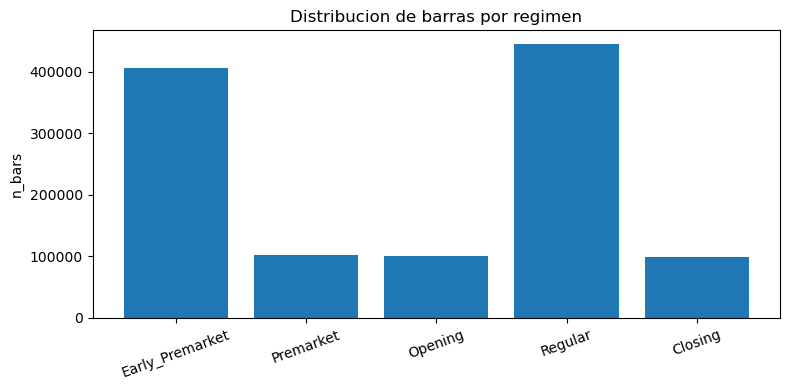

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(result.regime_dist["regime_label"], result.regime_dist["n_bars"])
ax.set_ylabel("n_bars")
ax.set_title("Distribucion de barras por regimen")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [11]:
# Convierte minute_of_day a formato HH:MM.
def minute_to_time(minute):
    hour = minute // 60
    minute_remainder = minute % 60
    return f"{hour:02d}:{minute_remainder:02d}"


# Obtiene los límites realmente observados en cada régimen.
regime_ranges = (
    df.groupby(["regime_id", "regime_label"])
      .agg(
          start_minute=("minute_of_day", "min"),
          end_minute=("minute_of_day", "max"),
          n_bars=("minute_of_day", "size"),
          n_days=("date", "nunique"),
      )
      .reset_index()
)

# Convierte los límites numéricos a horas legibles.
regime_ranges["start_time"] = regime_ranges["start_minute"].apply(minute_to_time)
regime_ranges["end_time"] = regime_ranges["end_minute"].apply(minute_to_time)

# Cantidad teórica de barras en un día completo.
regime_ranges["bars_per_full_day"] = (
    regime_ranges["end_minute"]
    - regime_ranges["start_minute"]
    + 1
)

# Ordena las columnas para facilitar la lectura.
regime_ranges = regime_ranges[
    [
        "regime_id",
        "regime_label",
        "start_time",
        "end_time",
        "start_minute",
        "end_minute",
        "bars_per_full_day",
        "n_bars",
        "n_days",
    ]
]

regime_ranges

,regime_id,regime_label,start_time,end_time,start_minute,end_minute,bars_per_full_day,n_bars,n_days
0,0,Early_Premarket,04:30,08:29,270,509,240,406383,1720
1,1,Premarket,08:30,09:29,510,569,60,101777,1708
2,2,Opening,09:30,10:29,570,629,60,100425,1733
3,3,Regular,10:30,14:59,630,899,270,445326,1790
4,4,Closing,15:00,16:00,900,960,61,98599,1655


## 5. Clasificacion de jornadas (`trading_day_audit_v2.parquet`)

Ningun dia se excluye por conteo de barras ni por gaps: cada fecha
calendario del rango tiene un registro con motivo explicito.

* **`Total fechas auditadas`**: cantidad total de fechas calendario revisadas, incluyendo días con datos, fines de semana, feriados y fechas sin datos.
* **`day_status`**: explica qué ocurrió en cada fecha, por ejemplo:

  * `full_coverage`: jornada completa (691 barras, 691 timestamps unicos, un unico contrato, continuidad de un minuto).
  * `partial_undetermined`: jornada incompleta sin causa confirmada.
  * `partial_early_close_cme`: jornada parcial por cierre anticipado, **verificado** contra el calendario CME_Equity Y contra el patron exacto de datos (511 barras consecutivas, 04:30-13:00) -- no se asume solo por estar en el calendario.
  * `no_data_weekend`: fin de semana sin datos.
  * `no_data_cme_holiday`: feriado CME.
  * `no_data_gap_documented_s00`: ausencia asociada a un gap conocido de S00 (ninguna fecha vigente cae aqui: los gaps historicos M23 y H25-M25 ya no existen en los datos actuales).
* **`eligibility_category`**: indica si esa jornada puede utilizarse:

  * `full_day_eligible`: jornada completa apta, poblacion principal por defecto.
  * `early_close_eligible`: cierre anticipado verificado; **no** entra por defecto en la poblacion principal, solo en analisis secundarios o de robustez.
  * `partial_regime_eligible`: jornada parcial, pero con algún régimen completo.
  * `descriptive_only`: sirve solo para análisis descriptivo.
  * `not_model_eligible`: no debe utilizarse para modelado.


In [12]:
print("Total fechas auditadas:", len(result.audit_df))
print("\nPor day_status:")
print(result.audit_df["day_status"].value_counts())
print("\nPor eligibility_category:")
print(result.audit_df["eligibility_category"].value_counts())

Total fechas auditadas: 2414

Por day_status:
day_status
full_coverage              1570
no_data_weekend             509
partial_undetermined        275
partial_early_close_cme      40
no_data_cme_holiday          11
no_data_undetermined          9
Name: count, dtype: int64

Por eligibility_category:
eligibility_category
full_day_eligible          1570
not_model_eligible          529
descriptive_only            188
partial_regime_eligible      87
early_close_eligible         40
Name: count, dtype: int64


### Observaciones actualizadas


Se revisaron **2.414 fechas calendario** dentro del periodo completo (data/00_source ahora cubre hasta 2026-07-31), incluyendo jornadas con datos, fines de semana, feriados y fechas sin informacion.

**Estado de las jornadas**

* **1.570 `full_coverage`**: jornadas completas, con las 691 barras esperadas entre 04:30 y 16:00, un unico contrato y continuidad de un minuto.
* **509 `no_data_weekend`**: fines de semana sin datos.
* **275 `partial_undetermined`**: jornadas con datos incompletos cuya causa todavia no fue determinada.
* **40 `partial_early_close_cme`**: jornadas parciales verificadas contra el patron exacto de cierre anticipado (511 barras consecutivas, 04:30-13:00) Y contra el calendario oficial CME_Equity.
* **11 `no_data_cme_holiday`**: feriados identificados mediante el calendario CME.
* **9 `no_data_undetermined`**: fechas sin datos para las que todavia no se determino una causa.

Las categorias `no_data_gap_documented_s00` y `partial_gap_documented_s00` desaparecieron porque los gaps de M23 y H25-M25 fueron corregidos en los archivos fuente y sus referencias fueron eliminadas de `known_gaps` en `config/intraday_config.yaml` (ver `02_KNOWN_ISSUES_AND_INVALIDATED_RESULTS.md` SS4.1-bis).

**Elegibilidad para analisis o modelado**

* **1.570 `full_day_eligible`**: jornadas completas, aptas para utilizarse integramente como poblacion principal.
* **87 `partial_regime_eligible`**: jornadas incompletas, pero con al menos un regimen completo y consecutivo potencialmente aprovechable.
* **40 `early_close_eligible`**: jornadas de cierre anticipado CME verificado (511 barras, 04:30-13:00). No se incluye por defecto en la poblacion principal.
* **188 `descriptive_only`**: jornadas con informacion parcial que pueden utilizarse para analisis descriptivo, pero no cumplen las condiciones para modelado.
* **529 `not_model_eligible`**: fechas que no deben utilizarse para modelado (fines de semana, feriados o fechas sin datos).

**Conclusion**

En total, **1.570 jornadas son completamente utilizables**, **87 pueden utilizarse parcialmente por regimen** y **40 adicionales quedan disponibles como cierre anticipado verificado** para analisis secundarios.

Respecto a la version anterior de esta notebook, tres cambios sucesivos produjeron el estado actual: (1) actualizacion de `data/00_source/` (mas cobertura, gaps M23/H25-M25 resueltos), (2) resolucion de rollover con seleccion de contrato unico por fecha (seccion 6), y (3) la regla de respaldo 11 (seccion 6.7): cuando el contrato activo tiene 0 barras pero el entrante si tiene datos, se conserva la cobertura real del entrante para esa fecha puntual sin adelantar el cruce formal. Esto agrego `2025-03-17` (691 barras de M25) a `full_coverage`, sumando el `full_coverage` total de 1.569 a 1.570.

Las **275 jornadas `partial_undetermined`** y las **9 fechas `no_data_undetermined`** todavia requieren una auditoria especifica; no son atribuibles a rollover ni a los gaps ya resueltos de S00.

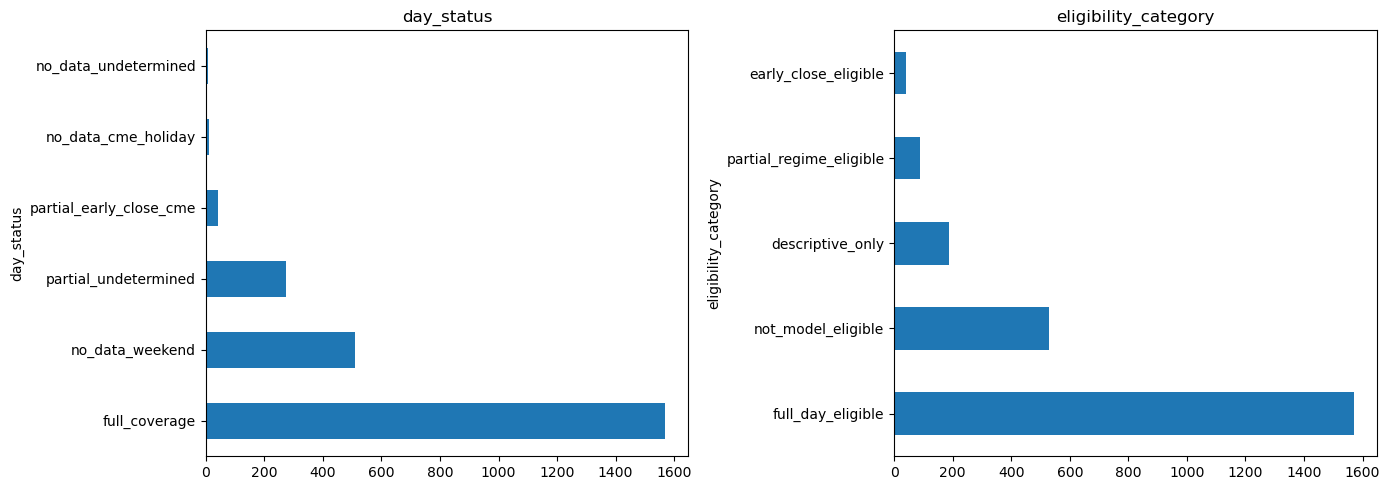

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
result.audit_df["day_status"].value_counts().plot(kind="barh", ax=axes[0])
axes[0].set_title("day_status")
result.audit_df["eligibility_category"].value_counts().plot(kind="barh", ax=axes[1])
axes[1].set_title("eligibility_category")
plt.tight_layout()
plt.show()

In [14]:
# Cuenta las jornadas clasificadas como completas.
full_days = (
    result.audit_df["day_status"] == prep.DAY_STATUS_FULL
).sum()

# Cuenta todas las fechas con menos barras que las 691 esperadas.
# Incluye jornadas parciales y fechas sin ninguna barra.
less_than_full = (
    result.audit_df["observed_bars"]
    < result.audit_df["expected_bars"]
).sum()

print(
    f"Jornadas con exactamente "
    f"{result.audit_df['expected_bars'].iloc[0]} barras: {full_days}"
)

print(
    f"Jornadas con menos de "
    f"{result.audit_df['expected_bars'].iloc[0]} barras: {less_than_full}"
)

# Selecciona solamente jornadas con alguna barra observada,
# pero que todavía tienen barras faltantes.
partial = result.audit_df[
    (result.audit_df["observed_bars"] > 0)
    & (result.audit_df["missing_bars"] > 0)
]

# Resume estadísticamente cuántas barras faltan en esas jornadas parciales.
print(partial["missing_bars"].describe())

Jornadas con exactamente 691 barras: 1570
Jornadas con menos de 691 barras: 844
count    315.000000
mean     476.269841
std      268.935031
min        1.000000
25%      180.000000
50%      689.000000
75%      690.000000
max      690.000000
Name: missing_bars, dtype: float64


In [15]:
# Agrega la cantidad de barras realmente disponibles.
partial_summary = (
    partial["missing_bars"]
    .value_counts()
    .sort_index()
    .rename("n_days")
    .reset_index()
)

partial_summary["observed_bars"] = (
    result.audit_df["expected_bars"].iloc[0]
    - partial_summary["missing_bars"]
)

partial_summary[
    ["missing_bars", "observed_bars", "n_days"]
]

,missing_bars,observed_bars,n_days
0,1,690,17
1,2,689,3
2,3,688,3
3,7,684,1
4,8,683,1
5,9,682,2
6,11,680,1
7,12,679,1
8,16,675,1
9,20,671,2


### Observaciones actualizadas

* Se auditaron jornadas con una expectativa de **691 barras**, correspondientes al intervalo de 04:30 a 16:00.

* Las **1.570 jornadas clasificadas como `full_coverage`** constituyen la parte principal y mas confiable del dataset.

* Existen **844 fechas con menos de 691 barras**:

  * **529 fechas no contienen ninguna barra**.
  * **315 fechas contienen datos, pero presentan una cobertura parcial**.

* La distribucion de las 315 jornadas parciales sigue siendo muy desigual. El promedio de **476 barras faltantes** no representa adecuadamente una jornada tipica, porque combina jornadas casi completas con otras practicamente vacias.

* La mediana de **689 barras faltantes** significa que la jornada parcial central conserva unicamente **2 de las 691 barras esperadas**.

* **169 de las 315 jornadas parciales** contienen solamente una o dos barras:

  * 126 jornadas contienen una sola barra.
  * 43 jornadas contienen dos barras (incluye `2025-03-16`, resuelta por la regla de respaldo 11 con 2 barras reales de M25).

* En total, **183 jornadas parciales contienen entre una y nueve barras observadas**, aproximadamente el **58 %** de las jornadas parciales. Estas fechas estan practicamente vacias y no deberian considerarse aprovechables para modelado.

* En el extremo contrario, existen jornadas casi completas: 23 jornadas conservan entre 688 y 690 barras (17 con 690, 3 con 689, 3 con 688). Estas jornadas requieren revisar donde se encuentran los minutos faltantes y si mantienen regimenes completos y consecutivos.

* El grupo de **40 jornadas con exactamente 511 barras observadas** es un patron sistematico, verificado empiricamente Y contra el calendario oficial `pandas_market_calendars` (CME_Equity): las 40 jornadas tienen barras consecutivas desde las 04:30 hasta las 13:00 y coinciden con el calendario de cierre anticipado -- por eso quedan clasificadas como `partial_early_close_cme` / `early_close_eligible`.

* Tambien persisten otros patrones repetidos: 11 jornadas con 526 barras, 4 con 301, 5 con 286 y 4 con 618. La repeticion de cantidades especificas sugiere truncamientos sistematicos, cierres de sesion o problemas de cobertura concretos, mas que perdidas aleatorias aisladas.

* La desviacion estandar de **269 barras** confirma que las jornadas parciales son muy heterogeneas y no deben tratarse mediante una unica regla.

* **Cero fechas** tienen 691 barras o mas sin quedar clasificadas `full_coverage` -- la ambiguedad que afectaba a 22 fechas por rollover sin resolver quedo cerrada por completo (seccion 6).

* La regla de respaldo 11 (seccion 6.7) agrego `2025-03-17` a `full_coverage` (691 barras reales de M25, contrato activo H25 sin barras ese dia) sin adelantar el cruce formal H25->M25, que sigue siendo 2025-03-18/2025-03-19.

### Conclusion

El dataset contiene una base solida de **1.570 jornadas completas**, mas **40 jornadas de cierre anticipado verificado** utilizables en analisis secundarios. Las 315 jornadas parciales restantes presentan situaciones muy diferentes y deben separarse entre jornadas casi completas, coberturas truncadas y fechas practicamente vacias. No corresponde aceptar ni excluir todas las jornadas parciales mediante una unica regla.

## 6. Resolucion de rollover y auditoria independiente

`resolve_rollovers` (en `src/data/s01_intraday_preparation.py`) construye
una serie principal con **un unico contrato por fecha** antes de asignar
regimenes, segmentos o auditar jornadas. Reglas resumidas (ver docstring
del modulo para el detalle completo):

1. Se detectan fechas con dos contratos dentro de 04:30-16:00.
2. El volumen se compara solo sobre los minutos compartidos por ambos contratos.
3. El contrato entrante confirma el cruce con >= 55% del volumen compartido.
4. Solo una sesion compartida COMPLETA (691/691 para ambos contratos) puede confirmar.
5. El nuevo contrato se aplica desde la siguiente jornada observada (no la fecha de la senal).
6. El cambio es irreversible.
7. Una sola sesion confirmante alcanza (no exige confirmacion doble).
8. Nunca se mezclan contratos dentro de una fecha.
9. No se promedia OHLCV ni se crean barras sinteticas.
10. Toda fila descartada queda trazada en un artefacto de auditoria.

Las fechas de transicion se derivan de los datos, nunca se hardcodean en el
modulo productivo.

In [16]:
# Transiciones de contrato CONFIRMADAS (una fila por evento).
# La fecha de senal usa todavia el contrato saliente; el entrante se
# activa recien desde effective_date (regla 5).
result.rollover_events

,signal_date,outgoing_contract,incoming_contract,effective_date,shared_minutes,outgoing_shared_volume,incoming_shared_volume,incoming_share
0,2024-12-17,Z24,H25,2024-12-18,691,371687.0,831350.0,0.691043
1,2025-03-18,H25,M25,2025-03-19,691,556353.0,1243482.0,0.690887
2,2026-06-15,M26,U26,2026-06-16,691,404958.0,1313912.0,0.764405


In [17]:
# Todas las fechas donde se detecto mas de un contrato dentro de la
# ventana (23 en los datos vigentes), confirmen o no el cruce. Incluye el
# detalle completo de la evaluacion: minutos compartidos, si la sesion fue
# completa (691/691) para ambos contratos, el share de volumen del
# entrante y si esa fecha confirmo o no el rollover.
with pd.option_context("display.max_rows", None, "display.width", 220):
    display(result.rollover_ambiguous.sort_values("date"))

,date,formal_active_contract,candidate_contract,outgoing_observed_minutes,incoming_observed_minutes,shared_minutes,both_full_691_session,outgoing_shared_volume,incoming_shared_volume,incoming_share,is_confirming_session,confirmed_here,selected_contract_for_date,selection_reason
0,2024-12-12,Z24,H25,691,660,660,False,1012705.0,18126.0,0.017584,False,False,Z24,ambiguous_not_full_691_session
1,2024-12-13,Z24,H25,691,691,691,True,1169365.0,46685.0,0.038391,True,False,Z24,ambiguous_full_session_below_threshold
2,2024-12-16,Z24,H25,691,691,691,True,502828.0,481387.0,0.489108,True,False,Z24,ambiguous_full_session_below_threshold
3,2024-12-17,Z24,H25,691,691,691,True,371687.0,831350.0,0.691043,True,True,Z24,confirmed_rollover_signal
4,2024-12-18,H25,Z24,691,691,691,True,1115853.0,277991.0,0.199442,False,False,H25,superseded_contract_residual_data
5,2024-12-19,H25,Z24,691,691,691,True,1318811.0,161251.0,0.108949,False,False,H25,superseded_contract_residual_data
6,2024-12-20,H25,Z24,691,300,300,False,360172.0,10852.0,0.029249,False,False,H25,superseded_contract_residual_data
7,2025-03-13,H25,M25,691,690,690,False,2283306.0,42284.0,0.018182,False,False,H25,ambiguous_not_full_691_session
8,2025-03-14,H25,M25,691,689,689,False,1785846.0,43631.0,0.023849,False,False,H25,ambiguous_not_full_691_session
9,2025-03-15,H25,M25,2,1,1,False,1.0,1.0,0.500000,False,False,H25,ambiguous_not_full_691_session


**Resultado sobre los datos vigentes (derivado, no hardcodeado):**

* **3 transiciones confirmadas**, las unicas 3 pares de contratos que
  llegaron a compartir una sesion completa de 691 minutos en los datos
  actuales (todas las transiciones anteriores, de H20 a Z24, son handoffs
  limpios sin solapamiento real):
  * `Z24 -> H25`: senal 2024-12-17 (share entrante 69,1%), `H25` activo desde `2024-12-18`.
  * `H25 -> M25`: senal 2025-03-18 (share entrante 69,1%), `M25` activo desde `2025-03-19`.
  * `M26 -> U26`: senal 2026-06-15 (share entrante 76,4%), `U26` activo desde `2026-06-16`.
* **`2025-03-15` no confirma el cruce**: esa fecha no es una sesion
  compartida completa (H25 solo tiene 2 minutos, M25 solo 1) -- la regla 4
  la descarta directamente, sin importar el share.
* **`2026-06-11` conserva `M26`**: no es una sesion compartida completa
  (M26 646/691, U26 636/691) y el share de U26 (1,3%) esta muy por debajo
  del umbral. La fecha se clasifica por la cobertura REAL de M26 (646
  barras), sin rellenar ni mezclar con U26.
* **`2025-03-16` y `2025-03-17`** (H25 con 0 barras esos dias, dentro de la
  ventana de solapamiento H25->M25 todavia sin confirmar) aplican la
  **regla de respaldo 11** (ver seccion 6.7): como M25 SI tiene datos esos
  dias, se conserva su cobertura real -- 2 barras el 16, 691 barras
  (sesion completa) el 17. El 2025-03-17 queda `full_coverage` /
  `full_day_eligible`. Esto **no** adelanta el cruce formal: la senal
  sigue siendo el 2025-03-18, efectiva desde el 2025-03-19.

In [18]:
# Artefacto de auditoria: TODAS las filas descartadas por la resolucion de
# rollover, con motivo (rollover_discarded_rows_v2.parquet). Nunca se
# borran silenciosamente -- quedan trazadas para cualquier revision futura.
discarded = pd.read_parquet(result.rollover_discarded_path)
print("Filas descartadas por rollover:", len(discarded))
print("\nPor motivo:")
print(discarded["discard_reason"].value_counts())
print("\nPor contrato descartado:")
print(discarded["contract"].value_counts())

Filas descartadas por rollover: 13854

Por motivo:
discard_reason
superseded_contract_residual_data         5049
ambiguous_not_full_691_session            4659
ambiguous_full_session_below_threshold    2073
confirmed_rollover_signal                 2073
Name: count, dtype: int64

Por contrato descartado:
contract
H25    4417
U26    4001
M25    2071
M26    1683
Z24    1682
Name: count, dtype: int64


In [19]:
# Verificacion directa sobre la serie resuelta: cero fechas con mas de un
# contrato, cero timestamps duplicados.
n_multi_contract_dates = (
    result.df_window.groupby("date")["contract"].nunique() > 1
).sum()
dup_ts = result.df_window.reset_index().duplicated(subset=["date", "minute_of_day"]).sum()

print("Fechas con mas de un contrato en la serie final:", n_multi_contract_dates)
print("Timestamps (date, minute_of_day) duplicados en la serie final:", dup_ts)

assert n_multi_contract_dates == 0
assert dup_ts == 0

print("\nOK: un unico contrato por fecha, cero duplicados de timestamp.")

Fechas con mas de un contrato en la serie final: 0
Timestamps (date, minute_of_day) duplicados en la serie final: 0

OK: un unico contrato por fecha, cero duplicados de timestamp.


### 6.3. Auditoria de cierre: conteo de transiciones, conservacion y calendario oficial

Correccion respecto a un borrador previo de este analisis: el numero
correcto de transiciones de contrato es **26** (27 contratos, no 25) y los
handoffs limpios son **23** (no 22). El conteo de abajo se genera
programaticamente desde `data/01_raw/mnq_raw_v2.parquet`, no a mano.

In [20]:
# Config necesaria para esta seccion (se recarga aqui por si esta
# celda se ejecuta antes de la seccion 6 original de la notebook).
config = prep.load_config(CONFIG_PATH)

# Conteo verificado de transiciones de contrato: un contrato por fecha de
# PRIMERA aparicion, sin asumir ningun numero de antemano.
first_seen = result.df_window.groupby("contract").apply(lambda g: g["date"].min(), include_groups=False).sort_values()
contracts_order = list(first_seen.index)
print("Contratos en el historial completo:", len(contracts_order))
print("Transiciones posibles (contratos - 1):", len(contracts_order) - 1)

n_confirmed = len(result.rollover_events)
n_clean = (len(contracts_order) - 1) - n_confirmed
print(f"Transiciones confirmadas por volumen: {n_confirmed}")
print(f"Handoffs limpios (sin solapamiento real): {n_clean}")

assert len(contracts_order) - 1 == 26
assert n_clean == 23
print("\nOK: 26 transiciones totales, 23 handoffs limpios, 3 confirmadas por volumen.")

Contratos en el historial completo: 27
Transiciones posibles (contratos - 1): 26
Transiciones confirmadas por volumen: 3
Handoffs limpios (sin solapamiento real): 23

OK: 26 transiciones totales, 23 handoffs limpios, 3 confirmadas por volumen.


In [21]:
# Validacion de conservacion, persistida en el manifest (bloqueante dentro
# de resolve_rollovers y build_manifest -- no solo en esta celda).
rollover_manifest = result.manifest["rollover"]
print("n_rows_pre_rollover:", rollover_manifest["n_rows_pre_rollover"])
print("n_rows_resolved:", rollover_manifest["n_rows_resolved"])
print("n_discarded_rows:", rollover_manifest["n_discarded_rows"])
print("conservation_check:", rollover_manifest["conservation_check"])
print("conservation_check_passed:", rollover_manifest["conservation_check_passed"])

assert rollover_manifest["conservation_check_passed"] is True
assert (
    rollover_manifest["n_rows_pre_rollover"]
    == rollover_manifest["n_rows_resolved"] + rollover_manifest["n_discarded_rows"]
)
print("\nOK: filas_pre_rollover = filas_resueltas + filas_descartadas.")

n_rows_pre_rollover: 1166364
n_rows_resolved: 1152510
n_discarded_rows: 13854
conservation_check: 1166364 == 1152510 + 13854
conservation_check_passed: True

OK: filas_pre_rollover = filas_resueltas + filas_descartadas.


### 6.4. Verificacion de `partial_early_close_cme` contra calendario oficial versionado

Las 40 fechas no se clasifican solo por tener 511 barras de 04:30 a
13:00: se exige ADEMAS que esa fecha este declarada como cierre
anticipado en `pandas_market_calendars` (calendario `CME_Equity`), un
paquete externo versionado que modela el calendario publicado por CME
Group -- no una tabla inventada por este pipeline.

In [22]:
import pandas_market_calendars as mcal

print("pandas_market_calendars version:", mcal.__version__)
print("Calendario:", type(mcal.get_calendar("CME_Equity")).__name__)

early_close_dates = sorted(result.audit_df.loc[
    result.audit_df["day_status"] == prep.DAY_STATUS_PARTIAL_EARLY_CLOSE, "date"
].tolist())
print("\nFechas clasificadas partial_early_close_cme:", len(early_close_dates))

cal_dict = prep.get_cme_early_close_dates(
    pd.Timestamp(min(early_close_dates)).date(), pd.Timestamp(max(early_close_dates)).date()
)
not_in_calendar = [d for d in early_close_dates if d not in cal_dict]
print("Fechas NO encontradas en el calendario oficial (debe ser vacio):", not_in_calendar)

assert not not_in_calendar, "Hay fechas partial_early_close_cme sin respaldo en el calendario oficial"
print("\nOK: las 40 fechas estan confirmadas por calendario oficial versionado, no solo por el patron de 511 barras.")

verified = pd.DataFrame([
    {"date": d, "weekday": pd.Timestamp(d).day_name(), "cme_declared_close_time": cal_dict[d]}
    for d in early_close_dates
])
verified.to_csv(PROJECT_ROOT / "reports" / "stage_reports" / "s01_early_close_dates_verified.csv", index=False)
verified

pandas_market_calendars version: 5.4.0
Calendario: CMEEquityExchangeCalendar

Fechas clasificadas partial_early_close_cme: 40


Fechas NO encontradas en el calendario oficial (debe ser vacio): []

OK: las 40 fechas estan confirmadas por calendario oficial versionado, no solo por el patron de 511 barras.


,date,weekday,cme_declared_close_time
0,2020-02-17,Monday,13:00
1,2020-05-25,Monday,13:00
2,2020-07-03,Friday,13:00
3,2020-09-07,Monday,13:00
4,2020-11-26,Thursday,13:00
5,2021-01-18,Monday,13:00
6,2021-02-15,Monday,13:00
7,2021-05-31,Monday,13:00
8,2021-07-05,Monday,13:00
9,2021-09-06,Monday,13:00


### 6.5. Tres estados de S01 (para no confundir shapes de distinto origen)

Separa el efecto de la actualización de `data/00_source/` del efecto de
resolver el rollover.

In [23]:
# Estado intermedio: datos actuales (fuente ya actualizada), pero ANTES de
# resolver rollover -- recalculado directamente aqui, sin el requisito de
# contrato unico (equivalente a la logica anterior al fix, aplicada a los
# datos ya actualizados).
df_raw_full = pd.read_parquet(PROJECT_ROOT / "data" / "01_raw" / "mnq_raw_v2.parquet")
_tz_table = prep.evaluate_timezone_hypotheses(
    df_raw_full.index, df_raw_full["volume"].to_numpy(), config["timezone"]["candidates"]
)
_tz_sel = prep.select_timezone(_tz_table)
_idx_ny = prep.convert_to_ny(df_raw_full.index, _tz_sel["timezone_selected"])
_df_ny = df_raw_full.copy()
_df_ny.index = _idx_ny
df_window_pre_rollover = prep.filter_window(_df_ny, config["window"])

expected_bars = config["window"]["expected_minutes"]
old_style_full = 0
for _, g in df_window_pre_rollover.groupby("date"):
    minutes = g["minute_of_day"].to_numpy()
    if len(minutes) == expected_bars and len(set(minutes.tolist())) == expected_bars:
        old_style_full += 1

print("=== Tres estados de S01 ===")
print(f"{'Estado':<55}{'Filas':>12}{'full_coverage':>16}")
print(f"{'Artefacto historico (fuente vieja, sin rollover)':<55}{1_087_777:>12,}{1_482:>16,}")
print(f"{'Datos actuales, ANTES de resolver rollover':<55}{len(df_window_pre_rollover):>12,}{old_style_full:>16,}")
print(f"{'Resultado final (fuente actualizada + rollover resuelto)':<55}{len(result.df_window):>12,}{(result.audit_df['day_status']==prep.DAY_STATUS_FULL).sum():>16,}")

assert len(df_window_pre_rollover) == 1_166_364
assert old_style_full == 1_549
print("\nOK: estado intermedio verificado = 1.166.364 filas, 1.549 full_coverage (estilo anterior al fix).")

=== Tres estados de S01 ===
Estado                                                        Filas   full_coverage
Artefacto historico (fuente vieja, sin rollover)          1,087,777           1,482
Datos actuales, ANTES de resolver rollover                1,166,364           1,549
Resultado final (fuente actualizada + rollover resuelto)   1,152,510           1,570

OK: estado intermedio verificado = 1.166.364 filas, 1.549 full_coverage (estilo anterior al fix).


**Artefacto de auditoría por transición:** una fila por cada una de las 26
transiciones, mostrando si tuvo algún solapamiento real y si se confirmó
por volumen (usa `df_window_pre_rollover`, ya calculado arriba).

In [24]:
transition_rows = []
for i in range(len(contracts_order) - 1):
    out_c, in_c = contracts_order[i], contracts_order[i + 1]
    out_dates = set(df_window_pre_rollover[df_window_pre_rollover["contract"] == out_c]["date"])
    in_dates = set(df_window_pre_rollover[df_window_pre_rollover["contract"] == in_c]["date"])
    shared_dates = sorted(out_dates & in_dates)
    confirmed_row = result.rollover_events[
        (result.rollover_events["outgoing_contract"] == out_c)
        & (result.rollover_events["incoming_contract"] == in_c)
    ]
    transition_rows.append({
        "transition_n": i + 1,
        "outgoing": out_c,
        "incoming": in_c,
        "n_shared_dates": len(shared_dates),
        "clean_handoff": len(shared_dates) == 0,
        "confirmed_by_volume": not confirmed_row.empty,
        "signal_date": confirmed_row["signal_date"].iloc[0] if not confirmed_row.empty else None,
    })

transition_audit = pd.DataFrame(transition_rows)
transition_audit.to_csv(PROJECT_ROOT / "reports" / "stage_reports" / "s01_rollover_transition_audit.csv", index=False)
display(transition_audit)

assert len(transition_audit) == 26
assert transition_audit["clean_handoff"].sum() == 23
assert transition_audit["confirmed_by_volume"].sum() == 3
assert ((~transition_audit["clean_handoff"]) & (~transition_audit["confirmed_by_volume"])).sum() == 0
print("\nOK: 26 transiciones, 23 handoffs limpios, 3 confirmadas -- ningun solapamiento real quedo sin confirmar.")

,transition_n,outgoing,incoming,n_shared_dates,clean_handoff,confirmed_by_volume,signal_date
0,1,H20,M20,0,True,False,None
1,2,M20,U20,0,True,False,None
2,3,U20,Z20,0,True,False,None
3,4,Z20,H21,0,True,False,None
4,5,H21,M21,0,True,False,None
5,6,M21,U21,0,True,False,None
6,7,U21,Z21,0,True,False,None
7,8,Z21,H22,0,True,False,None
8,9,H22,M22,0,True,False,None
9,10,M22,U22,0,True,False,None



OK: 26 transiciones, 23 handoffs limpios, 3 confirmadas -- ningun solapamiento real quedo sin confirmar.


### 6.6. Tabla completa de las 25 fechas evaluadas: contrato, volumen, day_status antes/después

Identifica explícitamente las 3 fechas que NO quedaron `full_coverage` (2025-03-17 se resuelve por la regla de respaldo 11, seccion 6.7, y SI queda `full_coverage`).

In [25]:
by_date_pre = {d: g for d, g in df_window_pre_rollover.groupby("date")}
audit_after_idx = result.audit_df.set_index("date")

rows_tbl = []
for _, r in result.rollover_ambiguous.iterrows():
    d = r["date"]
    day_raw = by_date_pre[d]
    active_c, cand_c = r["formal_active_contract"], r["candidate_contract"]
    out_rows = len(day_raw[day_raw["contract"] == active_c])
    in_rows = len(day_raw[day_raw["contract"] == cand_c])
    minutes = day_raw["minute_of_day"].to_numpy()
    old_full = len(minutes) == expected_bars and len(set(minutes.tolist())) == expected_bars
    chosen = r["selected_contract_for_date"]
    discarded_c = cand_c if chosen == active_c else active_c
    rows_tbl.append({
        "date": d,
        "contracts": f"{active_c}/{cand_c}",
        f"{active_c}_rows": out_rows,
        f"{cand_c}_rows": in_rows if active_c != cand_c else None,
        "shared_volume_out": r["outgoing_shared_volume"],
        "shared_volume_in": r["incoming_shared_volume"],
        "contract_selected": chosen,
        "contract_discarded": discarded_c,
        "day_status_before (old-style, sin contrato unico)": "full_coverage" if old_full else "no full_coverage",
        "day_status_after": audit_after_idx.loc[d, "day_status"] if d in audit_after_idx.index else "N/A",
        "reason": r["selection_reason"],
    })

overlap_table = pd.DataFrame(rows_tbl).sort_values("date")
overlap_table.to_csv(PROJECT_ROOT / "reports" / "stage_reports" / "s01_rollover_overlap_dates_full_table.csv", index=False)

with pd.option_context("display.max_rows", None, "display.width", 260, "display.max_columns", 20):
    display(overlap_table)

not_full = overlap_table[overlap_table["day_status_after"] != prep.DAY_STATUS_FULL]
print(f"\nFechas que NO quedaron full_coverage tras la resolucion ({len(not_full)}):")
display(not_full[["date", "contract_selected", "day_status_after", "reason"]])
assert len(not_full) == 3

,date,contracts,Z24_rows,H25_rows,shared_volume_out,shared_volume_in,contract_selected,contract_discarded,"day_status_before (old-style, sin contrato unico)",day_status_after,reason,M25_rows,M26_rows,U26_rows
0,2024-12-12,Z24/H25,691.0,660.0,1012705.0,18126.0,Z24,H25,no full_coverage,full_coverage,ambiguous_not_full_691_session,NaN,NaN,NaN
1,2024-12-13,Z24/H25,691.0,691.0,1169365.0,46685.0,Z24,H25,no full_coverage,full_coverage,ambiguous_full_session_below_threshold,NaN,NaN,NaN
2,2024-12-16,Z24/H25,691.0,691.0,502828.0,481387.0,Z24,H25,no full_coverage,full_coverage,ambiguous_full_session_below_threshold,NaN,NaN,NaN
3,2024-12-17,Z24/H25,691.0,691.0,371687.0,831350.0,Z24,H25,no full_coverage,full_coverage,confirmed_rollover_signal,NaN,NaN,NaN
4,2024-12-18,H25/Z24,691.0,691.0,1115853.0,277991.0,H25,Z24,no full_coverage,full_coverage,superseded_contract_residual_data,NaN,NaN,NaN
5,2024-12-19,H25/Z24,691.0,691.0,1318811.0,161251.0,H25,Z24,no full_coverage,full_coverage,superseded_contract_residual_data,NaN,NaN,NaN
6,2024-12-20,H25/Z24,300.0,691.0,360172.0,10852.0,H25,Z24,no full_coverage,full_coverage,superseded_contract_residual_data,NaN,NaN,NaN
7,2025-03-13,H25/M25,NaN,691.0,2283306.0,42284.0,H25,M25,no full_coverage,full_coverage,ambiguous_not_full_691_session,690.0,NaN,NaN
8,2025-03-14,H25/M25,NaN,691.0,1785846.0,43631.0,H25,M25,no full_coverage,full_coverage,ambiguous_not_full_691_session,689.0,NaN,NaN
9,2025-03-15,H25/M25,NaN,2.0,1.0,1.0,H25,M25,no full_coverage,partial_undetermined,ambiguous_not_full_691_session,1.0,NaN,NaN



Fechas que NO quedaron full_coverage tras la resolucion (3):


,date,contract_selected,day_status_after,reason
9,2025-03-15,H25,partial_undetermined,ambiguous_not_full_691_session
10,2025-03-16,M25,partial_undetermined,active_contract_no_data_fallback_to_incoming
19,2026-06-11,M26,partial_undetermined,ambiguous_not_full_691_session


### 6.7. Regla de respaldo (11): activo con 0 barras, entrante con datos

Si el contrato activo tiene EXACTAMENTE 0 barras una fecha pero el
entrante SI tiene datos, se selecciona la cobertura real del entrante
para ESA fecha puntual (motivo `active_contract_no_data_fallback_to_incoming`).
No mezcla contratos (el activo no aporta nada ese dia), no crea barras
sinteticas, y **no adelanta formalmente el contrato activo** -- el cruce
formal sigue dependiendo exclusivamente de la confirmacion por volumen
(reglas 3-4).

In [26]:
fallback_rows = result.rollover_ambiguous[
    result.rollover_ambiguous["selection_reason"] == "active_contract_no_data_fallback_to_incoming"
]
display(fallback_rows[[
    "date", "formal_active_contract", "candidate_contract", "incoming_observed_minutes", "selected_contract_for_date",
]])
print("Fechas resueltas por la regla de respaldo:", len(fallback_rows))

,date,formal_active_contract,candidate_contract,incoming_observed_minutes,selected_contract_for_date
10,2025-03-16,H25,M25,2,M25
11,2025-03-17,H25,M25,691,M25


Fechas resueltas por la regla de respaldo: 2


In [27]:
# Caso de regresion obligatorio: 2025-03-17.
d = pd.Timestamp("2025-03-17").date()
sub = result.df_window[result.df_window["date"] == d]
print("Contrato(s) el 2025-03-17:", sub["contract"].unique().tolist())
print("Barras:", len(sub))

audit_row = result.audit_df[result.audit_df["date"] == d].iloc[0]
print("day_status:", audit_row["day_status"])
print("eligibility_category:", audit_row["eligibility_category"])
print("is_model_eligible:", audit_row["is_model_eligible"])

assert sub["contract"].unique().tolist() == ["M25"]
assert len(sub) == 691
assert audit_row["day_status"] == prep.DAY_STATUS_FULL
assert audit_row["eligibility_category"] == prep.ELIGIBILITY_FULL

row = result.rollover_events[result.rollover_events["outgoing_contract"] == "H25"].iloc[0]
print("Senal formal H25->M25:", row["signal_date"], "-> activo desde", row["effective_date"])
assert str(row["signal_date"]) == "2025-03-18"
assert str(row["effective_date"]) == "2025-03-19"

print("OK: 2025-03-17 conserva M25 (691 barras, full_coverage/full_day_eligible); el cruce formal H25->M25 sigue siendo 2025-03-18 / 2025-03-19, sin adelantarse.")


Contrato(s) el 2025-03-17: ['M25']
Barras: 691


day_status: full_coverage
eligibility_category: full_day_eligible
is_model_eligible: True
Senal formal H25->M25: 2025-03-18 -> activo desde 2025-03-19
OK: 2025-03-17 conserva M25 (691 barras, full_coverage/full_day_eligible); el cruce formal H25->M25 sigue siendo 2025-03-18 / 2025-03-19, sin adelantarse.


In [28]:
# 2025-03-16 (cobertura parcial real del entrante, sin completar ni rellenar).
d16 = pd.Timestamp("2025-03-16").date()
sub16 = result.df_window[result.df_window["date"] == d16]
audit16 = result.audit_df[result.audit_df["date"] == d16].iloc[0]
print("2025-03-16 -> contrato:", sub16["contract"].unique().tolist(), "barras:", len(sub16))
print("day_status:", audit16["day_status"], "| eligibility_category:", audit16["eligibility_category"])
assert sub16["contract"].unique().tolist() == ["M25"]
assert len(sub16) == 2  # cobertura parcial real, no completada

2025-03-16 -> contrato: ['M25'] barras: 2
day_status: partial_undetermined | eligibility_category: descriptive_only


### 6.1. Auditoria independiente por fecha (verificacion cruzada)

Recalcula, directamente desde `result.df_window` (la serie YA resuelta),
si cada jornada `full_coverage` realmente tiene 691 timestamps unicos,
consecutivos, con el regimen correcto y un unico contrato -- sin confiar en
las columnas que ya calculo `build_trading_day_audit`. Es una segunda
implementacion independiente a proposito, para detectar posibles
discrepancias entre lo reportado y lo real.

In [29]:
import numpy as np
import pandas as pd


# ============================================================
# 1. CONFIGURACIÓN ESPERADA
# ============================================================

config = prep.load_config(CONFIG_PATH)

start_minute = int(config["window"]["start_minute"])
end_minute = int(config["window"]["end_minute"])
expected_bars = int(config["window"]["expected_minutes"])

expected_minutes = np.arange(
    start_minute,
    end_minute + 1
)

assert len(expected_minutes) == expected_bars == 691


# Mapa esperado: minute_of_day -> regime_id
expected_regime_by_minute = {}

# Cantidad esperada de barras por régimen.
expected_regime_counts = {}

for regime in config["regimes"]:
    regime_id = int(regime["regime_id"])
    regime_start = int(regime["start_minute"])
    regime_end = int(regime["end_minute"])

    regime_minutes = range(
        regime_start,
        regime_end + 1
    )

    expected_regime_counts[regime_id] = (
        regime_end - regime_start + 1
    )

    for minute in regime_minutes:
        if minute in expected_regime_by_minute:
            raise AssertionError(
                f"El minuto {minute} está asignado a más de un régimen."
            )

        expected_regime_by_minute[minute] = regime_id


assert set(expected_regime_by_minute) == set(expected_minutes)


# ============================================================
# 2. PREPARACIÓN DE LOS DATOS
# ============================================================

bars = result.df_window.copy().reset_index()

# El índice temporal pasa a una columna estándar.
timestamp_column = bars.columns[0]

bars = bars.rename(
    columns={timestamp_column: "timestamp"}
)

bars["timestamp"] = pd.to_datetime(
    bars["timestamp"]
)

bars["date_key"] = pd.to_datetime(
    bars["date"]
).dt.date


# ============================================================
# 3. AUDITORÍA TEMPORAL DE CADA FECHA
# ============================================================

def audit_one_day(day_df):

    day_df = day_df.sort_values(
        ["timestamp", "contract"]
    ).copy()

    timestamps = day_df["timestamp"]
    minutes = day_df["minute_of_day"].astype(int)

    row_count = len(day_df)

    unique_timestamp_count = timestamps.nunique()
    unique_minute_count = minutes.nunique()

    duplicate_timestamp_rows = int(
        timestamps.duplicated(keep=False).sum()
    )

    duplicate_minute_rows = int(
        minutes.duplicated(keep=False).sum()
    )

    observed_minute_set = set(minutes.tolist())
    expected_minute_set = set(expected_minutes.tolist())

    missing_minutes = sorted(
        expected_minute_set - observed_minute_set
    )

    extra_minutes = sorted(
        observed_minute_set - expected_minute_set
    )

    # Se utilizan timestamps únicos para detectar saltos internos reales.
    unique_timestamps = (
        timestamps
        .drop_duplicates()
        .sort_values()
    )

    timestamp_deltas = (
        unique_timestamps
        .diff()
        .dropna()
        .dt.total_seconds()
    )

    internal_gap_count = int(
        (timestamp_deltas > 60).sum()
    )

    non_one_minute_steps = int(
        (timestamp_deltas != 60).sum()
    )

    exact_minute_set = (
        observed_minute_set == expected_minute_set
        and unique_minute_count == expected_bars
    )

    exact_boundaries = (
        minutes.min() == start_minute
        and minutes.max() == end_minute
    )

    consecutive_timestamps = (
        unique_timestamp_count == expected_bars
        and non_one_minute_steps == 0
    )

    # Verifica que cada minuto tenga el regime_id correcto.
    expected_regime_ids = minutes.map(
        expected_regime_by_minute
    )

    regime_assignment_ok = (
        expected_regime_ids.notna().all()
        and (
            day_df["regime_id"].astype(int).to_numpy()
            == expected_regime_ids.astype(int).to_numpy()
        ).all()
    )

    observed_regime_counts = (
        day_df["regime_id"]
        .astype(int)
        .value_counts()
        .sort_index()
        .to_dict()
    )

    regime_counts_ok = (
        observed_regime_counts == expected_regime_counts
    )

    # Definición estricta y comprobable de jornada completa.
    exact_full_coverage = all(
        [
            row_count == expected_bars,
            unique_timestamp_count == expected_bars,
            unique_minute_count == expected_bars,
            duplicate_timestamp_rows == 0,
            duplicate_minute_rows == 0,
            len(missing_minutes) == 0,
            len(extra_minutes) == 0,
            exact_minute_set,
            exact_boundaries,
            consecutive_timestamps,
            regime_assignment_ok,
            regime_counts_ok,
        ]
    )

    return pd.Series(
        {
            "actual_rows": row_count,
            "unique_timestamps": unique_timestamp_count,
            "unique_minutes": unique_minute_count,
            "duplicate_timestamp_rows": duplicate_timestamp_rows,
            "duplicate_minute_rows": duplicate_minute_rows,
            "missing_minute_count": len(missing_minutes),
            "extra_minute_count": len(extra_minutes),
            "internal_gap_count": internal_gap_count,
            "non_one_minute_steps": non_one_minute_steps,
            "first_minute": minutes.min(),
            "last_minute": minutes.max(),
            "regime_assignment_ok": regime_assignment_ok,
            "regime_counts_ok": regime_counts_ok,
            "exact_full_coverage": exact_full_coverage,
            "n_contracts": day_df["contract"].nunique(),
            "n_consecutive_segments": (
                day_df["consecutive_segment_id"].nunique()
                if "consecutive_segment_id" in day_df.columns
                else np.nan
            ),
        }
    )


daily_validation = (
    bars.groupby("date_key", sort=True)
    .apply(audit_one_day)
    .reset_index()
)


# ============================================================
# 4. CRUCE CON trading_day_audit_v2.parquet
# ============================================================

audit = result.audit_df.copy()

# Crea una clave común de fecha para unir ambas auditorías.
audit["date_key"] = pd.to_datetime(
    audit["date"]
).dt.date

# Conserva únicamente las columnas necesarias de la auditoría
# original de S01. Esto evita colisiones con las columnas
# calculadas nuevamente por la auditoría independiente.
audit_columns = [
    "date_key",
    "date",
    "day_status",
    "eligibility_category",
    "is_model_eligible",
    "observed_bars",
    "expected_bars",
]

audit = audit[audit_columns].copy()

# Une la clasificación original de S01 con la validación
# independiente calculada directamente desde las barras.
validation = audit.merge(
    daily_validation,
    on="date_key",
    how="left",
    validate="one_to_one",
)

# Las fechas sin datos no aparecen en df_window.
# Sus cantidades calculadas se completan con cero.
count_columns = [
    "actual_rows",
    "unique_timestamps",
    "unique_minutes",
    "duplicate_timestamp_rows",
    "duplicate_minute_rows",
    "missing_minute_count",
    "extra_minute_count",
    "internal_gap_count",
    "non_one_minute_steps",
    "n_contracts",
    "n_consecutive_segments",
]

validation[count_columns] = (
    validation[count_columns]
    .fillna(0)
    .astype(int)
)

# Las fechas sin datos no pueden superar las validaciones.
boolean_columns = [
    "regime_assignment_ok",
    "regime_counts_ok",
    "exact_full_coverage",
]

validation[boolean_columns] = (
    validation[boolean_columns]
    .fillna(False)
    .astype(bool)
)

# Clasificación informada originalmente por S01.
validation["reported_full_coverage"] = (
    validation["day_status"]
    == prep.DAY_STATUS_FULL
)

validation["reported_full_day_eligible"] = (
    validation["eligibility_category"]
    == "full_day_eligible"
)

# Verifica que observed_bars coincida con las filas reales.
validation["observed_bars_match"] = (
    validation["observed_bars"]
    == validation["actual_rows"]
)

# Compara la clasificación original con la verificación
# independiente de 691 minutos completos y consecutivos.
validation["classification_matches"] = (
    validation["reported_full_coverage"]
    == validation["exact_full_coverage"]
)

validation["eligibility_matches"] = (
    validation["reported_full_day_eligible"]
    == validation["exact_full_coverage"]
)


# ============================================================
# 5. RESULTADOS COMPLETOS
# ============================================================

reported_full = validation[
    validation["reported_full_coverage"]
]

invalid_reported_full = validation[
    validation["reported_full_coverage"]
    & ~validation["exact_full_coverage"]
]

unreported_exact_full = validation[
    ~validation["reported_full_coverage"]
    & validation["exact_full_coverage"]
]

observed_count_errors = validation[
    ~validation["observed_bars_match"]
]

classification_errors = validation[
    ~validation["classification_matches"]
]

eligibility_errors = validation[
    ~validation["eligibility_matches"]
]

days_with_691_or_more_not_exact = validation[
    (validation["actual_rows"] >= expected_bars)
    & ~validation["exact_full_coverage"]
]


print("========== AUDITORÍA COMPLETA DE S01 ==========")

print("Fechas calendario auditadas:", len(validation))

print(
    "Jornadas full_coverage informadas:",
    len(reported_full)
)

print(
    "Jornadas completas verificadas independientemente:",
    int(validation["exact_full_coverage"].sum())
)

print(
    "full_coverage incorrectos:",
    len(invalid_reported_full)
)

print(
    "Jornadas completas no reconocidas por S01:",
    len(unreported_exact_full)
)

print(
    "Diferencias entre observed_bars y filas reales:",
    len(observed_count_errors)
)

print(
    "Errores de clasificación day_status:",
    len(classification_errors)
)

print(
    "Errores de eligibility_category:",
    len(eligibility_errors)
)

print(
    "Fechas con 691 o más filas, pero sin cobertura completa:",
    len(days_with_691_or_more_not_exact)
)


# Muestra íntegramente las fechas que explican la diferencia.
if not days_with_691_or_more_not_exact.empty:

    print(
        "\nFechas con 691 o más filas que NO son "
        "jornadas completas válidas:"
    )

    columns_to_show = [
        "date_key",
        "day_status",
        "eligibility_category",
        "observed_bars",
        "actual_rows",
        "unique_timestamps",
        "unique_minutes",
        "duplicate_timestamp_rows",
        "duplicate_minute_rows",
        "missing_minute_count",
        "extra_minute_count",
        "internal_gap_count",
        "non_one_minute_steps",
        "regime_assignment_ok",
        "regime_counts_ok",
        "n_contracts",
        "n_consecutive_segments",
    ]

    with pd.option_context(
        "display.max_rows",
        None,
        "display.max_columns",
        None,
        "display.width",
        240,
    ):
        display(
            days_with_691_or_more_not_exact[
                columns_to_show
            ].sort_values("date_key")
        )


# ============================================================
# 6. VALIDACIÓN BLOQUEANTE
# ============================================================

errors = []

if len(invalid_reported_full) > 0:
    errors.append(
        f"{len(invalid_reported_full)} días fueron marcados "
        "full_coverage sin cumplir los 691 minutos consecutivos."
    )

if len(unreported_exact_full) > 0:
    errors.append(
        f"{len(unreported_exact_full)} días cumplen todos los criterios "
        "pero S01 no los clasificó como full_coverage."
    )

if len(observed_count_errors) > 0:
    errors.append(
        f"{len(observed_count_errors)} días tienen diferencias entre "
        "observed_bars y las filas reales."
    )

if len(classification_errors) > 0:
    errors.append(
        f"{len(classification_errors)} días presentan una clasificación "
        "inconsistente."
    )

if len(eligibility_errors) > 0:
    errors.append(
        f"{len(eligibility_errors)} días presentan una categoría de "
        "elegibilidad inconsistente."
    )

if errors:
    raise AssertionError(
        "\n".join(errors)
    )

print(
    "\nVALIDACIÓN SUPERADA: todos los días full_coverage tienen "
    "exactamente 691 barras únicas y consecutivas, desde 04:30 hasta "
    "16:00, sin gaps, sin duplicados y con regímenes correctamente asignados."
)

========== AUDITORÍA COMPLETA DE S01 ==========
Fechas calendario auditadas: 2414
Jornadas full_coverage informadas: 1570
Jornadas completas verificadas independientemente: 1570
full_coverage incorrectos: 0
Jornadas completas no reconocidas por S01: 0
Diferencias entre observed_bars y filas reales: 0
Errores de clasificación day_status: 0
Errores de eligibility_category: 0
Fechas con 691 o más filas, pero sin cobertura completa: 0

VALIDACIÓN SUPERADA: todos los días full_coverage tienen exactamente 691 barras únicas y consecutivas, desde 04:30 hasta 16:00, sin gaps, sin duplicados y con regímenes correctamente asignados.


**Observacion definitiva para la notebook**

La auditoria independiente confirma que las 1.570 jornadas clasificadas
como `full_coverage` contienen exactamente 691 barras unicas y
consecutivas entre las 04:30 y las 16:00, de un unico contrato, sin
minutos faltantes, duplicados ni errores de asignacion de regimen. No se
encuentran clasificaciones incorrectas ni fechas con "691 barras o mas
pero sin `full_coverage`" (el problema que motivo la resolucion de
rollover en la seccion 6 esta cerrado: 0 discrepancias). Incluye
`2025-03-17`, resuelta por la regla de respaldo 11 (seccion 6.7).

### 6.2. Segmentos consecutivos

`consecutive_segments_v2.parquet` persiste, para cada fecha, el `segment_id`,
minuto de inicio, minuto de fin y longitud de cada corrida ininterrumpida
de minutos consecutivos (se reinicia en cada gap y en cada dia). Etapas
posteriores deben leer esto en vez de recalcular limites de segmento.

In [30]:
segments = pd.read_parquet(result.segment_summary_path)
print("Segmentos totales:", len(segments))
print("Segmentos de longitud 691 (jornada full_coverage completa en un solo segmento):",
      (segments["length"] == 691).sum())
segments.sort_values("length", ascending=False).head(10)

Segmentos totales: 2393
Segmentos de longitud 691 (jornada full_coverage completa en un solo segmento): 1570


,date,segment_id,contract,start_minute,end_minute,length
2392,2026-07-31,2392,U26,270,960,691
2391,2026-07-30,2391,U26,270,960,691
2390,2026-07-29,2390,U26,270,960,691
2389,2026-07-28,2389,U26,270,960,691
2388,2026-07-27,2388,U26,270,960,691
2370,2026-07-02,2370,U26,270,960,691
2369,2026-07-01,2369,U26,270,960,691
2368,2026-06-30,2368,U26,270,960,691
2367,2026-06-29,2367,U26,270,960,691
2366,2026-06-26,2366,U26,270,960,691


## 7. DST (Daylight Saving Time)

DST (*Daylight Saving Time*) corresponde al cambio estacional de horario aplicado en Nueva York. Esta validación comprueba que la conversión desde UTC hacia `America/New_York` no haya generado minutos duplicados o inconsistencias durante las fechas de transición entre 2020 y 2026.


In [31]:
print(json.dumps(result.manifest["dst_check"], indent=2, ensure_ascii=False))

{
  "dates_checked": 14,
  "dates_with_duplicates": {}
}


**Resultado**

Se verificaron **14 fechas de transición de horario de verano** entre 2020 y 2026.

El campo:

```text
    "dates_with_duplicates": {}
```

está vacío, lo que significa que **no se detectaron minutos duplicados en ninguna de las fechas revisadas**.

**Conclusión**

La conversión desde UTC hacia `America/New_York` manejó correctamente los cambios de horario de verano dentro de la ventana intradía analizada.


## 8. Notas


- La ventana `04:30-16:00` y los limites de regimen **no son quiebres
  estructurales optimos** (ver auditoria previa) -- se conservan por
  continuidad metodologica con S02-S07, no como un optimo derivado de los
  datos.
- `timezone_selected` es evidencia empirica robusta (alineacion con
  apertura/cierre/corte de mantenimiento, consistente entre EDT/EST), **no**
  una confirmacion documental del proveedor (`timezone_provider_confirmation: false`).
- `timestamp_semantics` permanece `unknown_not_confirmed`: no se desplazo
  ninguna barra.
- El patron recurrente 16:20-16:30 (2019-2021) queda documentado como
  hallazgo pendiente no bloqueante -- cae dentro de la ventana primaria pero
  no afecta ningun regimen completo (`Closing` termina en 16:00).
- Los gaps extraordinarios de M23 y H25-M25 fueron corregidos en los archivos fuente. Se regeneraron los artefactos de S00 y se eliminaron sus referencias estaticas de la configuracion de S01. Por lo tanto, ya no generan exclusiones de jornadas.
- S01 ahora resuelve el rollover de contratos antes de auditar jornadas
  (seccion 6): la serie principal tiene un unico contrato por fecha, cero
  timestamps duplicados y cero reversiones de contrato. La politica
  completa (deteccion, umbral de volumen, irreversibilidad, artefactos de
  auditoria) vive en `resolve_rollovers` (`src/data/s01_intraday_preparation.py`),
  no en esta notebook.
- S01 no decide los lookbacks de S05/S07: solo deja disponibles
  `consecutive_segment_id` (por barra), `consecutive_segments_v2.parquet`
  (resumen por segmento) y los limites de fecha/contrato/segmento
  necesarios para que etapas posteriores no crucen esos limites.